# 支持向量机 SVM

SVM 的核心目标不是简单“把两类分开”，而是找到一条间隔最大的决策边界。它相信：如果边界离两边样本都更远，那么模型通常会更稳健。

## 三个关键词
- 间隔 margin：分类边界到最近样本的距离。
- 支持向量：真正决定边界位置的那些关键样本。
- 核函数：把原本线性不可分的数据映射到更高维空间后再分开。


In [14]:
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

## 为什么要画决策边界

SVM 的魅力很大程度上来自几何直觉。把数据和边界画出来之后，你会更容易理解：
- 哪些点在“支撑”边界。
- 为什么最大间隔比随便画一条线更合理。


In [15]:
# 图形展示函数，包含决策边界和支持向量
def plot_decision_boundary_with_margin(X, y, model, title):
    # 设置图形大小
    plt.figure(figsize=(8, 6))

    # 定义网格范围
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # 预测网格中所有点的类别
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 计算决策函数的值，用于绘制支持向量和间隔
    decision_function = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    decision_function = decision_function.reshape(xx.shape)

    # 绘制决策边界和数据点
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    # 绘制支持向量
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
                facecolors='none', edgecolors='k', label='Support Vectors')

    # 绘制间隔
    plt.contour(xx, yy, decision_function, colors='k', levels=[-1, 0, 1], alpha=0.5,
                linestyles=['--', '-', '--'])

    plt.legend()
    plt.show()

## 线性可分时，SVM 在优化什么

对于线性可分问题，SVM 本质上是在最大化间隔，等价地可以写成最小化权重范数。这样做能让模型对小扰动更鲁棒。


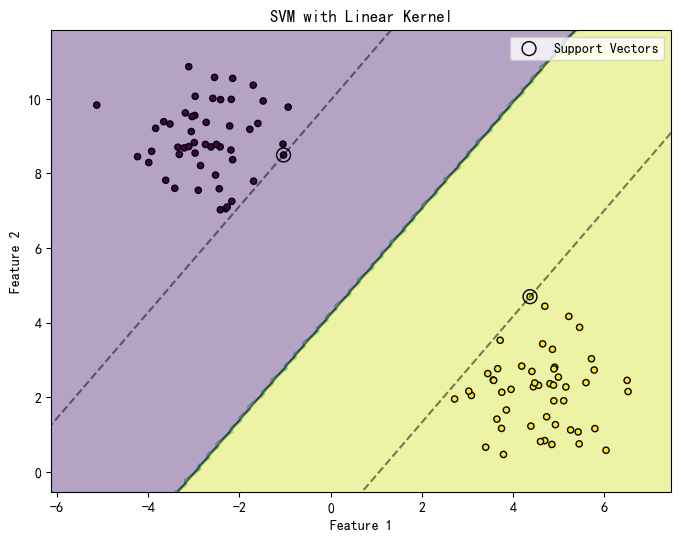

Classification Report for Linear SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [ ]:
# SVM
# 原理：SVM（Support Vector Machine）是一种监督学习算法，主要用于分类和回归任务。
# SVM的核心思想是找到一个最佳的超平面（在二维空间中是线，在高维空间中是一个平面）来最大化类别之间的间隔。
# 支持向量是那些距离决策边界最近的训练样本，它们对模型的构建起着关键作用。
# 优点：SVM在高维空间中表现良好，适用于非线性分类问题（通过核函数），并且在小样本数据集上也能取得不错的效果。
# 缺点：SVM在大规模数据集上训练时间较长，对参数选择敏感，且对噪声数据不太鲁棒。

# 简单二分类
X, y = make_blobs(n_samples=100, centers=2, random_state=42)

# 参数说明：
# kernel：核函数类型，常用的有'linear'（线性核）、'rbf'（径向基函数核）等。
# C：惩罚参数，控制模型对误分类的容忍度。较大的C值会使模型更严格地拟合训练数据，而较小的C值则允许更多的误分类，从而提高模型的泛化能力。
# gamma：核函数的参数，特别是在使用RBF核时，gamma控制数据点对决策边界的影响范围。
# 较大的gamma值会使模型更复杂，可能导致过拟合，而较小的gamma值则会使模型更简单，可能导致欠拟合。
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X, y)
plot_decision_boundary_with_margin(X, y, svm_linear, 'SVM with Linear Kernel')

y_pred_linear = svm_linear.predict(X)
print("Classification Report for Linear SVM:")
print(classification_report(y, y_pred_linear))

Support Vectors for Linear SVM: [[-1.03130358  8.49601591]
 [ 4.375222    4.69333885]]


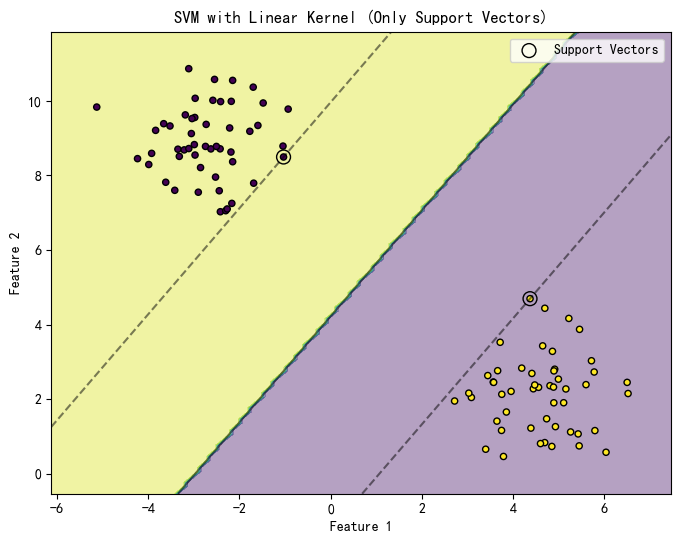

Classification Report for Linear SVM (Only Support Vectors):
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      50.0
           1       1.00      0.00      0.00      50.0
          29       0.00      1.00      0.00       0.0
          45       0.00      1.00      0.00       0.0

    accuracy                           0.00     100.0
   macro avg       0.50      0.50      0.00     100.0
weighted avg       1.00      0.00      0.00     100.0



In [ ]:
# 支持向量
# 支持向量是SVM模型中距离决策边界最近的训练样本，它们对模型的构建起着关键作用。
# 支持向量的数量和位置可以提供关于数据分布和模型复杂度的信息。
# 较少的支持向量通常意味着模型更简单，而较多的支持向量可能表明模型更复杂。

# 只通过支持向量训练
print("Support Vectors for Linear SVM:", svm_linear.support_vectors_)

X_support_linear = svm_linear.support_vectors_
y_support_linear = svm_linear.support_

svm_linear_only_support = SVC(kernel='linear', C=1)
svm_linear_only_support.fit(X_support_linear, y_support_linear)
plot_decision_boundary_with_margin(X, y, svm_linear_only_support,
                                   'SVM with Linear Kernel (Only Support Vectors)')
y_pred_linear_only_support = svm_linear_only_support.predict(X)
print("Classification Report for Linear SVM (Only Support Vectors):")
print(classification_report(y, y_pred_linear_only_support, zero_division=0))

## 核函数解决什么问题

当数据在线性空间里分不开时，不一定要直接手工构造高维特征。核函数让我们可以“隐式地”在高维空间计算内积，从而得到非线性边界。

常见核函数包括：
- 线性核
- 多项式核
- RBF 高斯核


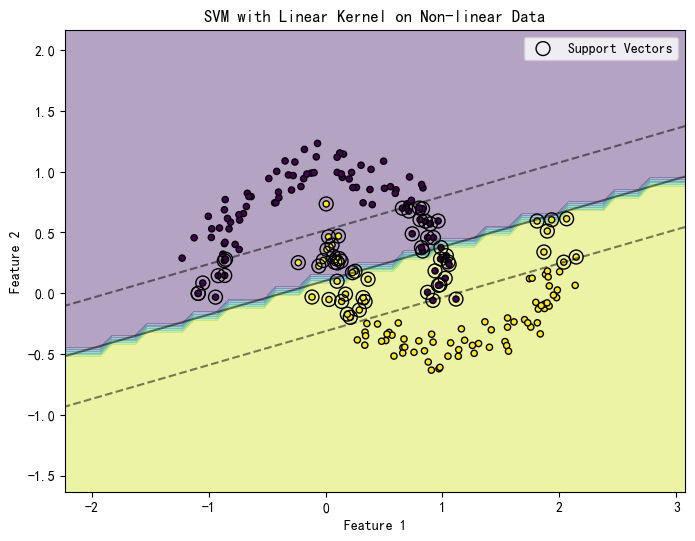

Classification Report for Linear SVM on Non-linear Data:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       100
           1       0.88      0.85      0.86       100

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200



In [20]:
# 核函数
# 核函数是SVM中用于处理非线性分类问题的工具。
# 它通过将输入数据映射到更高维的特征空间，使得在原始空间中非线性可分的数据在新空间中变得线性可分。
# 常见的核函数包括线性核、多项式核、径向基函数（RBF）核和sigmoid核。
# 选择合适的核函数对于SVM模型的性能至关重要，通常需要通过交叉验证来确定最佳的核函数和相关参数。

X_complex, y_complex = make_moons(n_samples=200, noise=0.1, random_state=42)
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_complex, y_complex)
plot_decision_boundary_with_margin(X_complex, y_complex, svm_linear,
                                   'SVM with Linear Kernel on Non-linear Data')
print("Classification Report for Linear SVM on Non-linear Data:")
y_pred_linear_complex = svm_linear.predict(X_complex)
print(classification_report(y_complex, y_pred_linear_complex, zero_division=0))

## 参数 `C` 和 `gamma` 怎么理解

- `C`：对误分类的容忍度。大 `C` 更强调把训练样本分对，小 `C` 更强调边界平滑。
- `gamma`：RBF 核影响范围。大 `gamma` 边界更弯曲，更容易贴着训练样本走。

这两个参数一起决定模型是更平滑还是更容易过拟合。


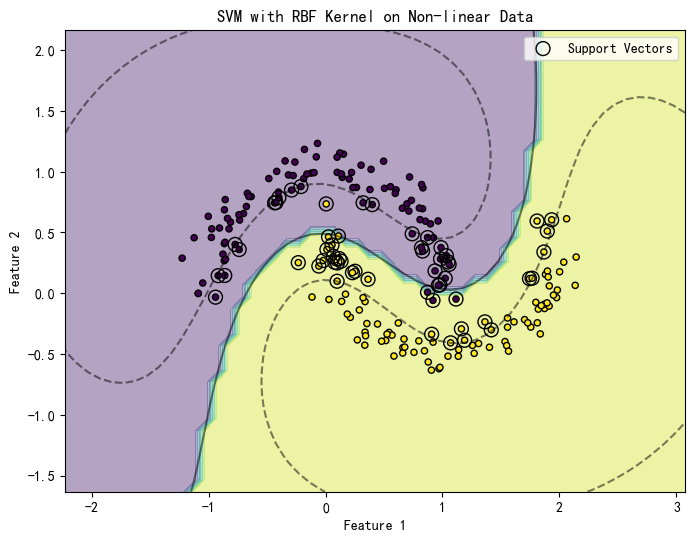

Classification Report for RBF SVM on Non-linear Data:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       100
           1       0.97      0.98      0.98       100

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



In [22]:
# 使用高斯核（RBF核）处理非线性数据
svm_rbf = SVC(kernel='rbf', C=1, gamma='auto')
svm_rbf.fit(X_complex, y_complex)
plot_decision_boundary_with_margin(X_complex, y_complex, svm_rbf,
                                   'SVM with RBF Kernel on Non-linear Data')
y_pred_rbf_complex = svm_rbf.predict(X_complex)
print("Classification Report for RBF SVM on Non-linear Data:")
print(classification_report(y_complex, y_pred_rbf_complex))

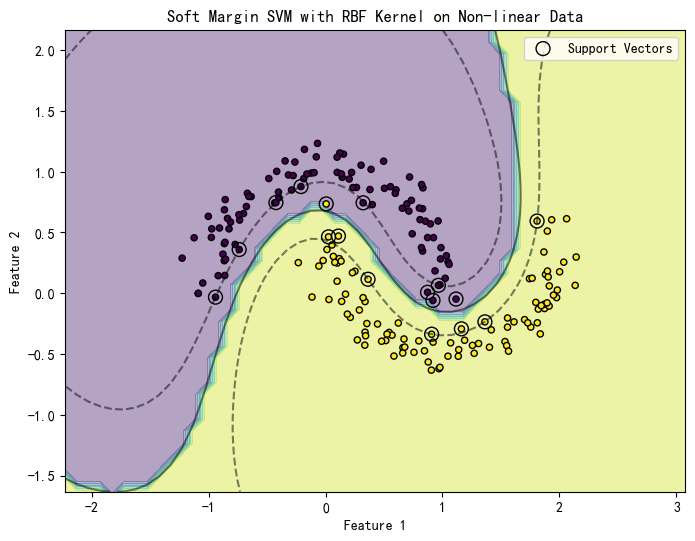

Classification Report for Soft Margin RBF SVM on Non-linear Data:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       1.00      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



In [28]:
# 软间隔
# 软间隔SVM允许一些数据点位于决策边界的错误一侧，通过引入惩罚参数C来控制模型对误分类的容忍度。
# 较大的C值会使模型更严格地拟合训练数据，而较小的C值则允许更多的误分类，从而可能提高模型的泛化能力。
# 选择合适的C值对于模型性能至关重要，通常需要通过交叉验证来确定最佳的C值。
# 在处理噪声数据或存在重叠类别时，软间隔SVM通常比硬间隔SVM表现更好，它允许模型在一定程度上容忍误分类，从而提高了模型的鲁棒性和泛化能力。

svm_rbf_soft = SVC(kernel='rbf', C=20, gamma='auto')
svm_rbf_soft.fit(X_complex, y_complex)
plot_decision_boundary_with_margin(X_complex, y_complex, svm_rbf_soft,
                                   'Soft Margin SVM with RBF Kernel on Non-linear Data')
y_pred_rbf_soft_complex = svm_rbf_soft.predict(X_complex)
print("Classification Report for Soft Margin RBF SVM on Non-linear Data:")
print(classification_report(y_complex, y_pred_rbf_soft_complex))

## 学习检查清单

完成本 notebook 后，可以尝试回答：
- 这个任务属于监督学习、无监督学习，还是特征处理流程？
- 当前算法依赖哪些关键假设，什么数据场景下可能失效？
- 代码中哪些步骤是在防止数据泄漏或过拟合？
- 如果指标不理想，应该优先调整特征、模型参数还是评估方式？
